In [ ]:
# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
# (5 points)
# TODO: Create the matrix described above
# Hint: Use np.ones and array slicing

import numpy as np

matrix = np.ones((5,5))
matrix[1:4,1:4] = 0
print(matrix)


[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [ ]:
# Task 2: Normalize a random array
# (5 points)
np.random.seed(42)
random_data = np.random.randn(100, 3)
# TODO: Normalize each column to have mean=0 and std=1

normalized = (random_data - random_data.mean(axis=0))/ random_data.std(axis=0)
print(normalized)




[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e-01 -5.06767212e-01  4.84818398e-01]
 [ 1.14447901e+00  1.14403850e+00 -8.25443216e-01]
 [-4.88601912e-01  5.28126505e-

In [ ]:
# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
#TODO: Calculate theta_hat using the normal equation.
#TODO: Print the estimated coefficients and compare with true_theta

import numpy as np
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1
print(true_theta)
theta_hat = np.linalg.inv((X.T)@X)@X.T@y
print(theta_hat)

print("The estimated theta and actual theta are quite close.")

[ 2.5 -1.2  3.7]
[ 2.51723721 -1.19783796  3.72399266]
The estimated theta and actual theta are quite close.


In [ ]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt


# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan



# Task 1: Data Cleaning and Exploration (10 points)
# TODO: Display basic information about the dataset


#These commands show different output that together describe the datset and give basic information like the columns, data types, number of entrie, i.e 200 , and son on.
print(df.head(20))
print(df.info())
print(df.describe())
print(df.shape)

# TODO: Identify and count missing values
df.isnull().sum()
# Before handling missing values, we can see from the output that there are missing values in exam scores and hours studied columns.



    student_id    major  year  exam_score  assignments_completed  \
0         1000  Physics     3   68.199753                     10   
1         1001  Biology     4   77.322537                      9   
2         1002       CS     3   77.930725                      9   
3         1003  Physics     1   67.856486                      2   
4         1004  Physics     4   93.657745                      6   
5         1005  Biology     1   79.738329                      2   
6         1006       CS     4   63.086965                      1   
7         1007       CS     4   81.565536                      9   
8         1008  Physics     2   65.253183                      3   
9         1009     Math     1   82.870846                      7   
10        1010  Physics     3   86.585956                      8   
11        1011  Physics     3   66.793177                      6   
12        1012  Physics     1   84.633761                      0   
13        1013  Physics     3   79.127809       

,0
student_id,0
major,0
year,0
exam_score,10
assignments_completed,0
hours_studied,5


In [ ]:

# TODO: Fill missing exam_score with the mean score for the student's major
df['exam_score']=df['exam_score'].fillna(df.groupby('major')['exam_score'].transform('mean'))


# TODO: Fill missing hours_studied with the median for the student's year
df['hours_studied']=df['hours_studied'].fillna(df.groupby('year')['hours_studied'].transform('median'))


df.isnull().sum()



,0
student_id,0
major,0
year,0
exam_score,0
assignments_completed,0
hours_studied,0


In [ ]:
# Task 2: Analysis (10 points)

import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Calculate and display the average exam_score by major

avg_scorebymajor = df.groupby('major')['exam_score'].mean()
print(avg_scorebymajor)

# TODO: Find the major with the highest average exam_score
print(avg_scorebymajor.idxmax())

# TODO: Calculate the correlation between hours_studied and exam_score
print(df['hours_studied'].corr(df['exam_score']))


# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
#To do this, a function would be created, taking the input of "scores" so that an accurate output description of the grade for a student would be given.


labels = [
    'Needs Improvement',
    'Average',
    'Good',
    'Excellent'
]

df['performance'] = pd.cut(
    df['exam_score'],
    bins=[0, 70, 80, 90, 100],
    labels=labels,
    include_lowest=True
)


print(df[['exam_score', 'performance']].head())


# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied

major_and_year_summary = df.groupby(['major','year']).agg(
    Number_of_Students=('exam_score','count'),
    Average_Score = ('exam_score', 'mean'),
    Average_Hours = ('hours_studied','mean'))

print(major_and_year_summary)




# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
top_students = df.nlargest(
    5,
    'exam_score'
)
# This allows us to go to the exam score column and pick out the 5 largest values.

print(top_students)

# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)

pivot = pd.pivot_table(
    df,
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
)

print(pivot)




major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64
CS
-0.055981383472924404
   exam_score        performance
0   68.199753  Needs Improvement
1   77.322537            Average
2   77.930725            Average
3   67.856486  Needs Improvement
4   93.657745          Excellent
              Number_of_Students  Average_Score  Average_Hours
major   year                                                  
Biology 1                     13      76.570059      12.677806
        2                     12      74.899613      13.426372
        3                     14      80.178476      14.486815
        4                     15      70.697689      14.253944
CS      1                     12      77.098194      13.039480
        2                      7      76.155936      13.995784
        3                      9      72.347626      15.039892
        4                     18      78.119997      16.275541
Math    1               

In [ ]:
# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied

df.groupby(['year','major']).agg(num_stu = ('student_id','count'), avg_score = ('exam_score','mean'), avg_hours = ('hours_studied','mean'))


# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
sorted_values = df.sort_values('exam_score', ascending=False)
print(sorted_values)
sorted_values.head(5)


df['position'] = df['exam_score'].rank(method='min', ascending=False)
first_students = df[df['position'] <= 5]
print(first_students)

# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
mean_scores = df.pivot_table(values= 'exam_score', index= 'major', columns='year', aggfunc= 'mean')

print(mean_scores)


     student_id    major  year  exam_score  assignments_completed  \
57         1057       CS     2  100.000000                      8   
27         1027     Math     2  100.000000                      4   
68         1068  Biology     3   98.146586                      1   
82         1082       CS     2   96.439441                      0   
132        1132       CS     4   96.330334                     10   
..          ...      ...   ...         ...                    ...   
71         1071     Math     4   58.872841                      8   
69         1069     Math     3   56.327348                      2   
133        1133       CS     3   55.479122                      1   
84         1084  Physics     2   54.748574                      0   
110        1110  Biology     4   42.587327                      4   

     hours_studied        performance  
57       11.870035          Excellent  
27        2.716265          Excellent  
68       11.379991          Excellent  
82        7

Text(0, 0.5, 'Exam Score')

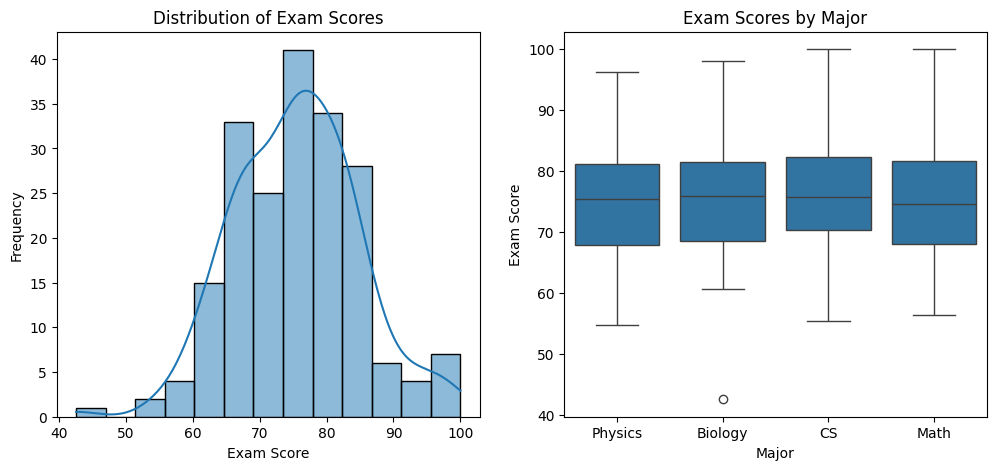

In [ ]:

"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""
# you can change the labels and titles.
import matplotlib.pyplot as plt
import seaborn as sns

# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
fig, axes = plt.subplots(1,2,figsize=(12,5))


#Left: Histogram of exam scores with KDE overlay
sns.histplot(
    data=df,
    x='exam_score',
    kde=True,
    ax=axes[0]
)

axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Frequency')


#       Right: Box plot of exam scores by major
sns.boxplot(
    data=df,
    x='major',
    y='exam_score',
    ax=axes[1]
)


# TODO: Add appropriate titles, labels, and styling

axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')




<Axes: xlabel='hours_studied', ylabel='exam_score'>

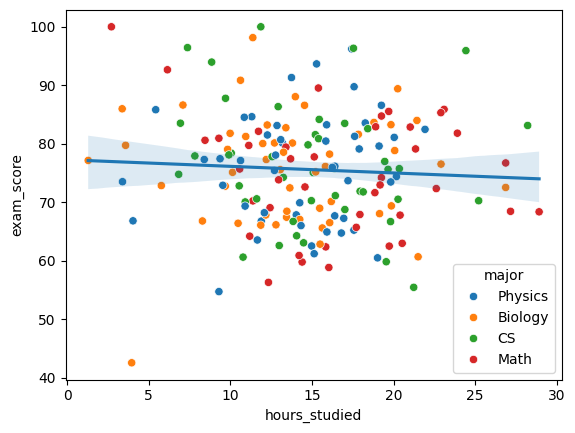

In [ ]:
# Task 2: Relationship Visualization (8 points)

import seaborn as sns
import matplotlib as plt
# TODO: Create a scatter plot of hours_studied vs exam_score
#plt.scatter(df['hours_studied'], df['exam_score'], alpha=0.6)

# TODO: Color points by major
# TODO: Add a regression line
# TODO: Include appropriate legends, titles, and axis labels
sns.scatterplot(data =df, x='hours_studied', y='exam_score',hue='major')

#The hue specifies which attribute should be colour classified, and the regplot is used to add the regression line whilst hiding its scatterplot points.

sns.regplot(data=df, x='hours_studied', y='exam_score',scatter=False)





performance_category
Fair         84
Good         83
Excellent    26
Poor          7
Name: count, dtype: int64


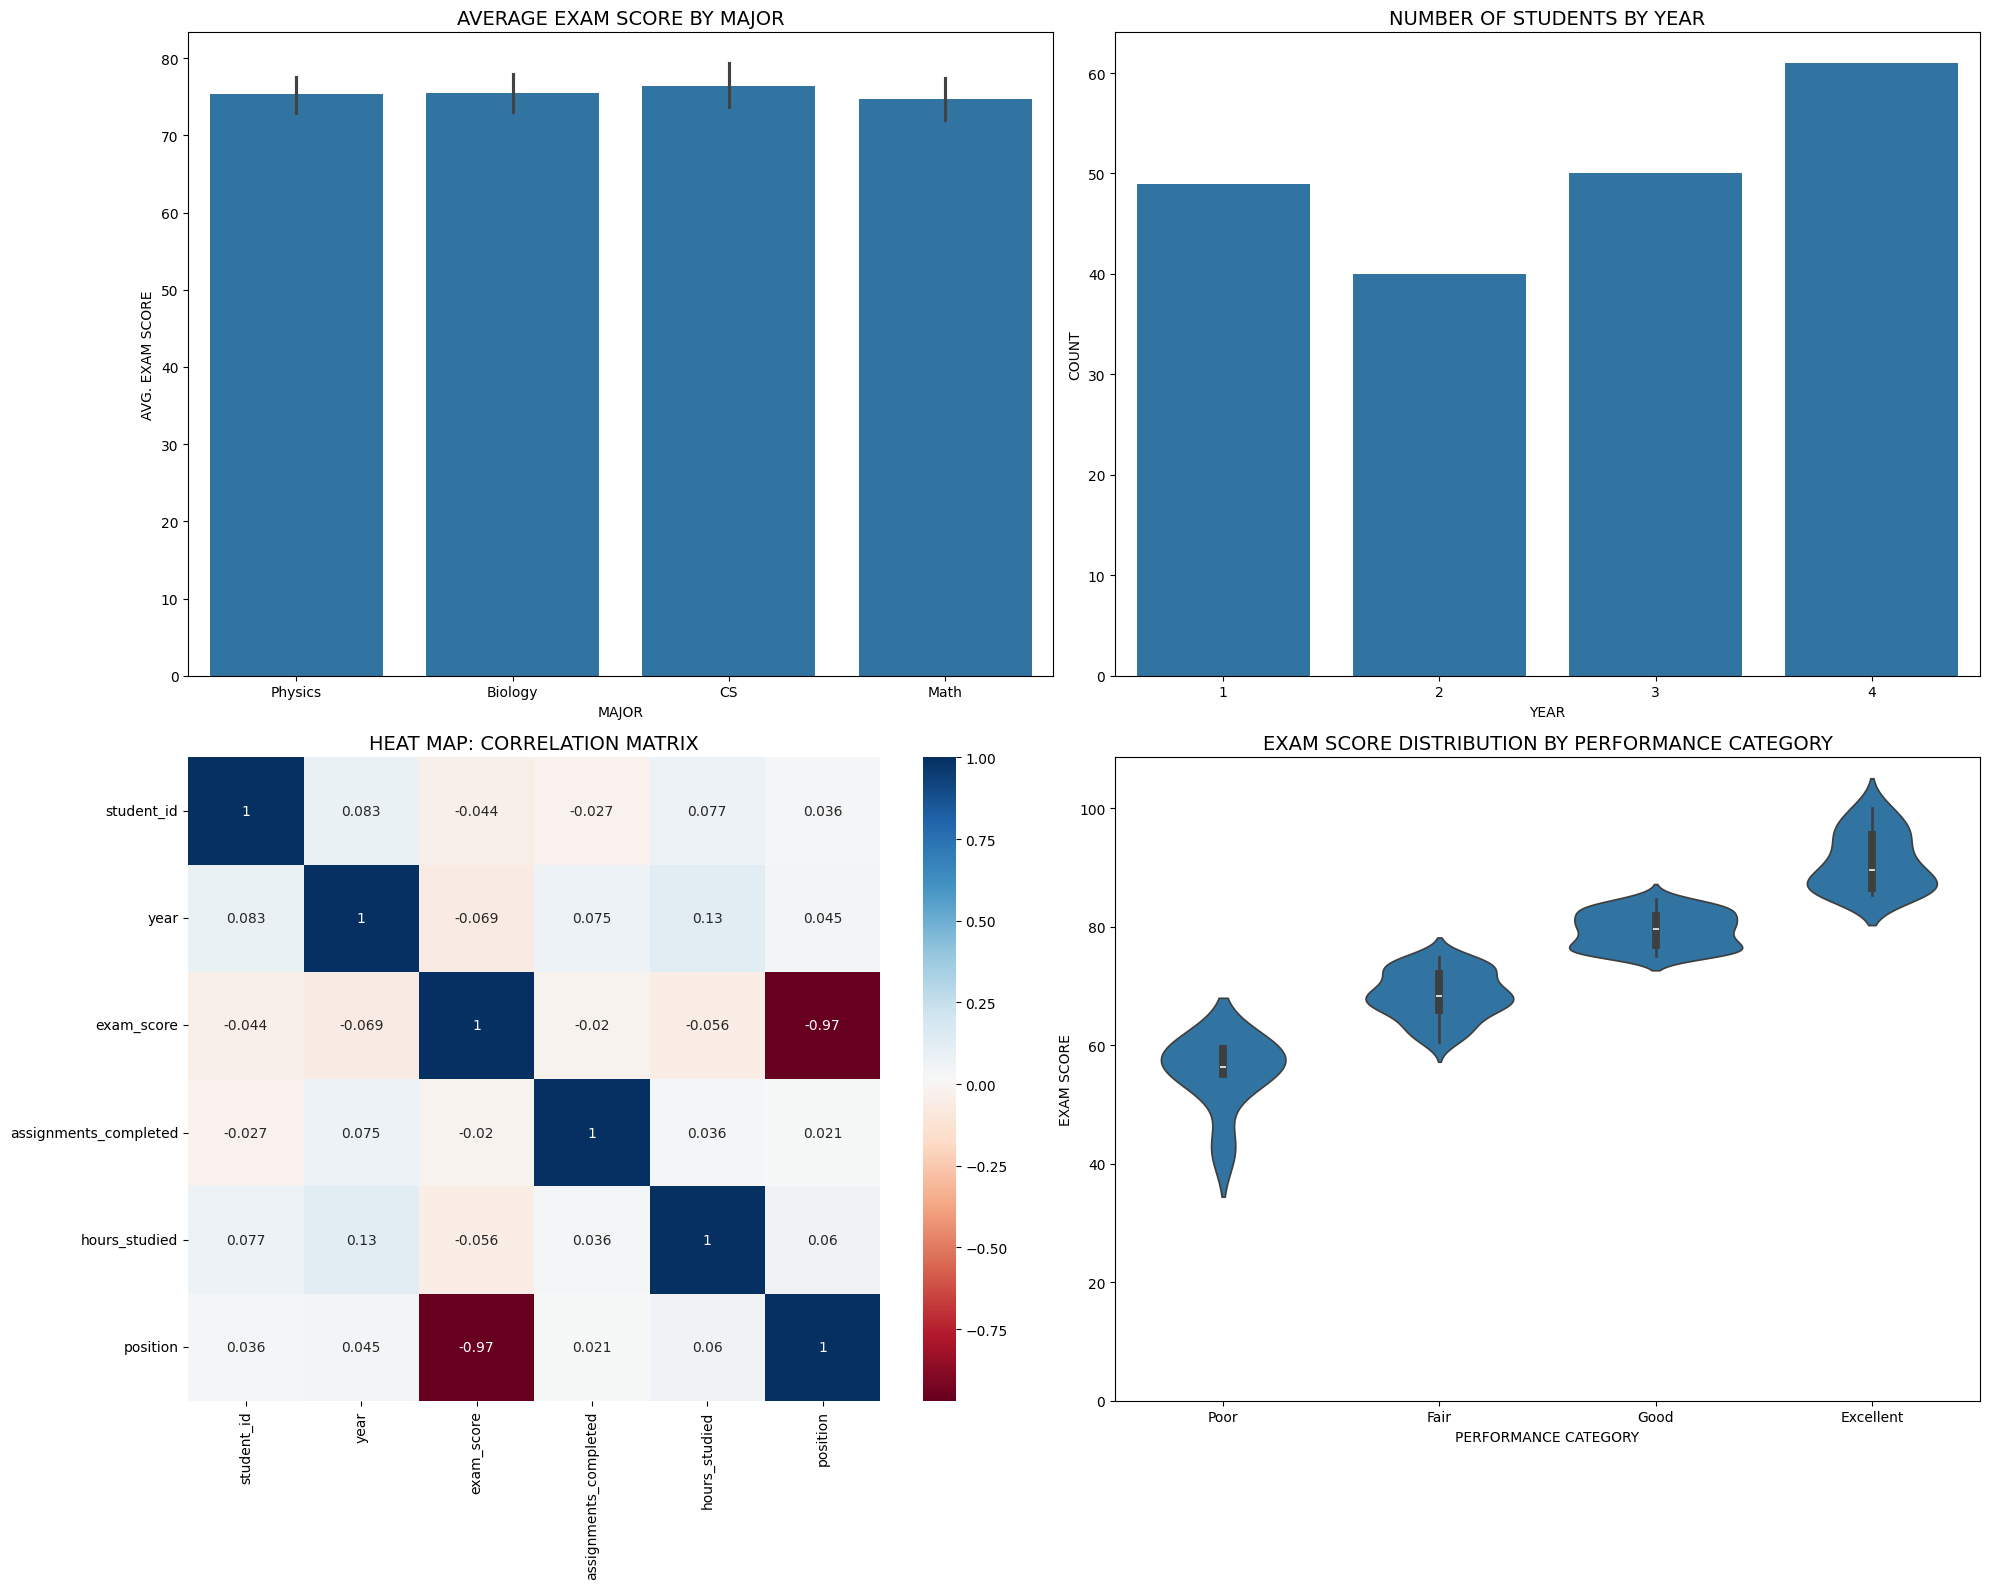

In [40]:
# Task 3: Advanced Dashboard (9 points)

import matplotlib.pyplot as plt
import seaborn as sns
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major

fig,axes = plt.subplots(2,2,figsize=(20,16)) # figsize allows to specify the divisons that should appear, where 2,2 means 2 rows and 2 columns.

#When creating the different plots in figsize, you must specify where in the axes they should appear using the row and column index.

avg_scores = df.groupby('major')['exam_score'].mean()


sns.barplot(
    data=df,
    x='major',
    y='exam_score',
    ax=axes[0,0]
)

#We can add appropriate titles and labels to the different axes in the figure by specifying the row and columns, staring from 0.
axes[0,0].set_title('AVERAGE EXAM SCORE BY MAJOR', fontsize=14)
axes[0,0].set_xlabel('MAJOR')
axes[0,0].set_ylabel('AVG. EXAM SCORE')

#       2. Count plot: Number of students by year

sns.countplot(
    data=df,
    x='year',
    ax=axes[0,1]
)

axes[0,1].set_title('NUMBER OF STUDENTS BY YEAR', fontsize=14)
axes[0,1].set_xlabel('YEAR')
axes[0,1].set_ylabel('COUNT')


#       3. Heat map: Correlation matrix of numerical columns
corr_matrix = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu',
    ax=axes[1,0]
)

axes[1,0].set_title('HEAT MAP: CORRELATION MATRIX',fontsize=14)


#       4. Violin plot: Exam score distribution by performance category

df['performance_category'] = pd.cut(
    df['exam_score'],
    bins=[0, 60,75,85, 100],
    labels=['Poor','Fair', 'Good', 'Excellent']
)

sns.violinplot(
    data=df,
    x='performance_category',
    y='exam_score',
    ax=axes[1,1]
)
axes[1,1].set_ylim(0, None)
axes[1,1].set_title('EXAM SCORE DISTRIBUTION BY PERFORMANCE CATEGORY', fontsize=14)
axes[1,1].set_xlabel('PERFORMANCE CATEGORY')
axes[1,1].set_ylabel('EXAM SCORE')

print(df['performance_category'].value_counts())


# TODO: Adjust layout, add titles, and ensure readability
plt.tight_layout()
plt.show()



In [37]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""
import pandas as pd
import numpy as np

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
max_frequency=customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (purchase_freq / max_frequency)
customers['CLV'] = purchase_freq * avg_purchase_value * (1 + customers['churn_risk'])
print(customers['churn_risk'])
print(customers['CLV'])

# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
customers['age_group'] = pd.cut(
    customers['age'],
    bins=[17,25,35,50,70],
    labels=['18-25', '26-35', '36-50', '51-70']
)
print(customers['age_group'])


# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV


age_description = customers.groupby('age_group').agg(
    Number_of_Customers=('age','count'),
    Average_Income=('income','mean'),
    Average_CLV=('CLV','mean'),
    Total_CLV=('CLV','sum')

)

print(age_description)


# TODO: Identify top 10% of customers by CLV
cutoff = customers['CLV'].quantile(0.90)
#This cutoff method uses quantile to identify the 90% percentile, and then we use this cutoff to identify the top 10% whose CLV values would be greater than or equal to it.
top_ten_customers = customers[
    customers['CLV'] >= cutoff
]

print(top_ten_customers.head())



0      0.416667
1      0.833333
2      0.750000
3      0.833333
4      0.333333
         ...   
495    0.666667
496    0.833333
497    0.833333
498    0.416667
499    0.750000
Name: churn_risk, Length: 500, dtype: float64
0       937.397271
1       370.085023
2       418.424348
3       477.171887
4      1097.651683
          ...     
495     750.052567
496     408.682977
497     276.305018
498    1149.667906
499     780.543489
Name: CLV, Length: 500, dtype: float64
0      51-70
1      51-70
2      36-50
3      26-35
4      51-70
       ...  
495    51-70
496    36-50
497    51-70
498    51-70
499    18-25
Name: age_group, Length: 500, dtype: category
Categories (4, object): ['18-25' < '26-35' < '36-50' < '51-70']
           Number_of_Customers  Average_Income  Average_CLV      Total_CLV
age_group                                                                 
18-25                       81    50634.018330   718.371170   58188.064760
26-35                       73    48747.148046   747

/tmp/ipykernel_294/2298668464.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_description = customers.groupby('age_group').agg(


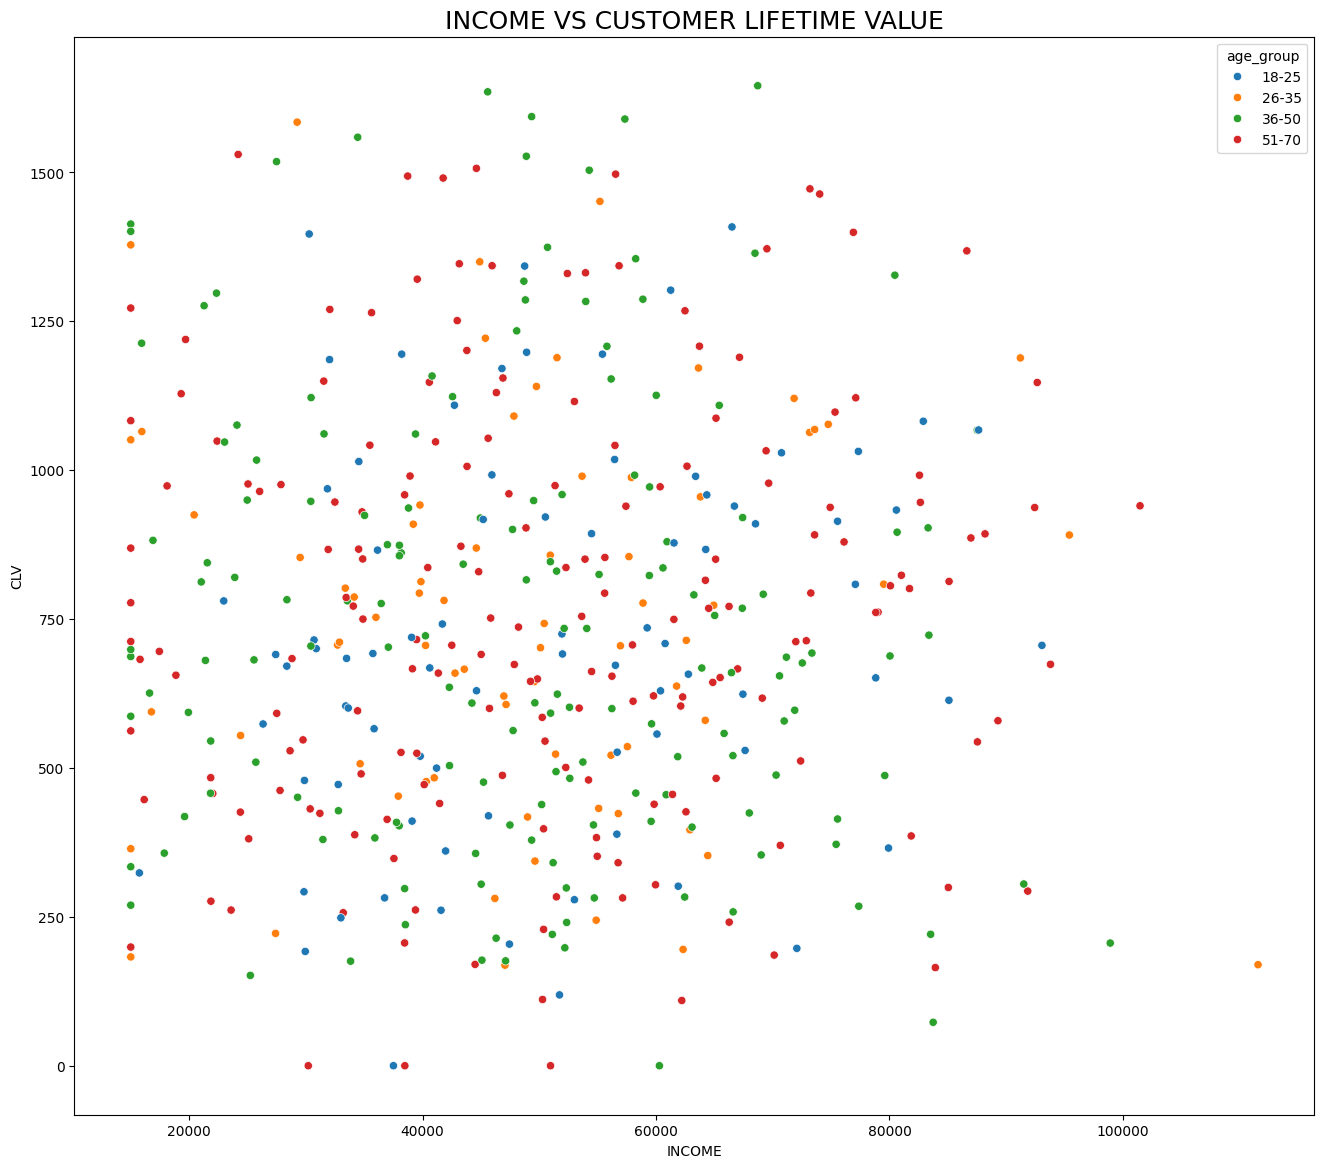

In [ ]:
# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,14))


sns.scatterplot(data=customers,
x='income',
y='CLV',
hue='age_group'
                )

#We colour according to the age group of the customers.

plt.title('INCOME VS CUSTOMER LIFETIME VALUE', fontsize=18
)
plt.xlabel('INCOME')
plt.ylabel('CLV')

plt.show()


/tmp/ipykernel_294/3673549637.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = customers.groupby('age_group')['CLV'].mean().reset_index()


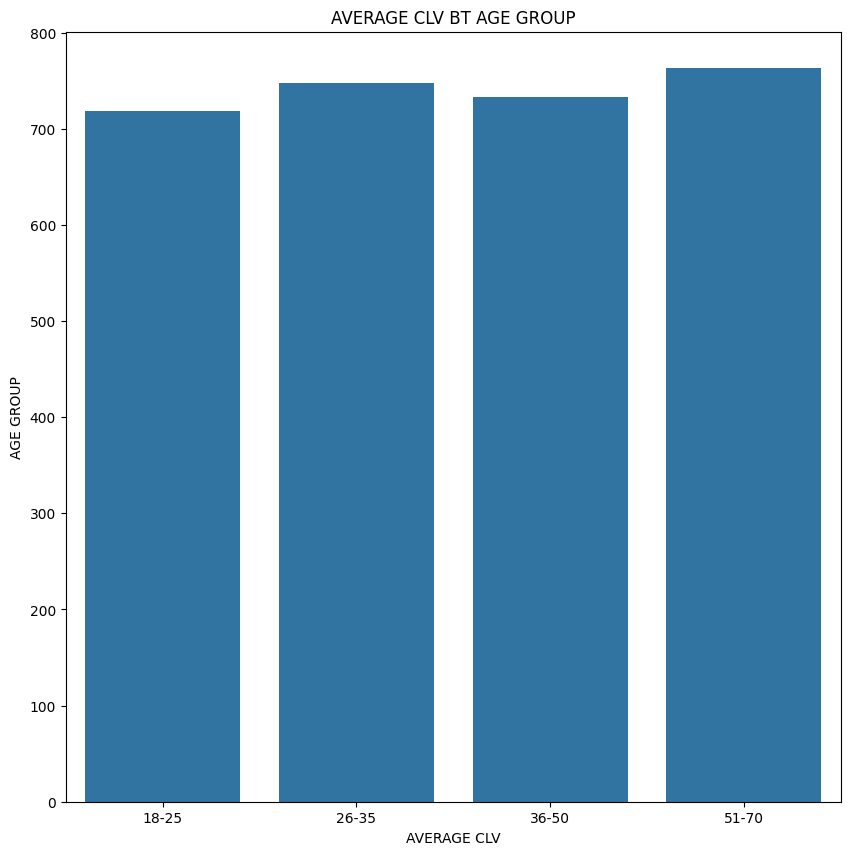

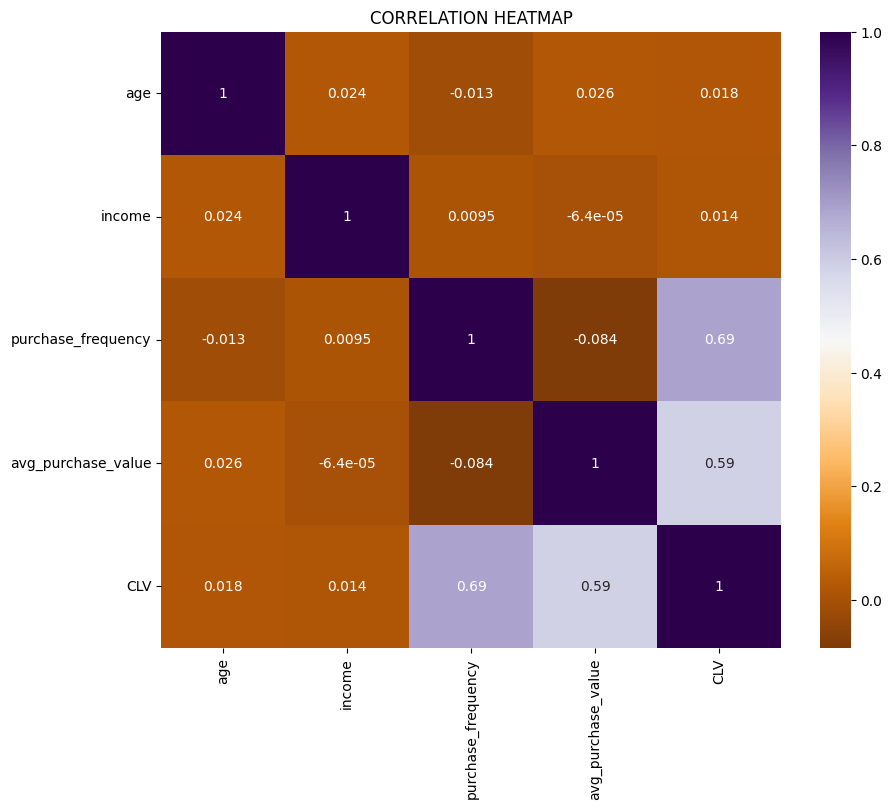

In [43]:
#       2. Bar chart of average CLV by age group
grouped = customers.groupby('age_group')['CLV'].mean().reset_index()

plt.figure(figsize=(10,10))

sns.barplot(
    data=grouped,
    x='age_group',
    y='CLV'
)

plt.title("AVERAGE CLV BT AGE GROUP")

plt.xlabel('AVERAGE CLV')
plt.ylabel('AGE GROUP')

plt.show()

#       3. Correlation heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    customers[['age','income','purchase_frequency','avg_purchase_value','CLV']].corr(),
    annot=True,
    cmap='PuOr'
)

plt.title("CORRELATION HEATMAP")
plt.show()


# TODO: Write a brief analysis paragraph (as a markdown cell)
# summarizing key findings and recommendations
  For this e-commerce company, the customer data provides insights relating to customer ages , income and their corresponding lifetime values. The age groups 26-35, as well as 51-70 tend to achieve higher CLV values, as oberved from the bar chart above. This makes them more of an asset to this e-commerce company. Additionally, the scatterplot does not show any strong relationship between income and lifetime values of customers(CLV). This implies a weak correlation. The heatmap also shows that CLV is more related to the average purchase value, meaning that customers that purchase more have a higher CLV. It also asserts what we observed from the scatterplot showing a very weak relationship between income and CLV. This informs the e-commerce company that purchasing frequency affects CLV the most so they can try to increase purchasing frequency and pay more attention to the behaviours of customers rather than demographics like age and income.


